# 3장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 폴더: /Users/038y_/Desktop/Data_Scientist/CH2/실습/Product_Analytics
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [2]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [3]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [4]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

In [5]:
# TODO: 테이블별 EDA 요약표를 만드세요.

summary_rows = []

for name, df in data.items():

    # 날짜 컬럼
    dates = date_columns[name]

    # 해당 테이블의 모든 날짜값을 하나로 모음
    all_dates = pd.concat(
        [df[col] for col in dates],
        ignore_index=True
    )

    summary_rows.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing": df.isnull().sum().sum(),
        "duplicates": df.duplicated().sum(),
        "date_min": all_dates.min(),
        "date_max": all_dates.max()
    })


# 요약표
eda_summary = pd.DataFrame(summary_rows)

display(eda_summary)

,table,rows,columns,missing,duplicates,date_min,date_max
0,accounts,500,10,0,0,2023-01-02,2024-12-31 00:00:00
1,subscriptions,5000,14,4514,0,2023-01-09,2024-12-31 00:00:00
2,feature_usage,25000,8,0,0,2023-01-01,2024-12-31 00:00:00
3,support_tickets,2000,9,825,0,2023-01-02,2024-12-31 19:00:00
4,churn_events,600,9,148,0,2023-01-25,2024-12-31 00:00:00


In [6]:
# ============================================================
# 결측치 요약표
# ============================================================

missing_list = []

for name, df in data.items():

    for col in df.columns:

        count = df[col].isnull().sum()

        if count > 0:

            missing_list.append({
                "table": name,
                "column": col,
                "missing_count": count,
                "missing_rate": count / len(df) * 100
            })


missing_summary = pd.DataFrame(missing_list)

if len(missing_summary) > 0:

    missing_summary["missing_rate"] = (
        missing_summary["missing_rate"].round(2)
    )

    display(missing_summary)

else:

    print("결측치가 없습니다.")

,table,column,missing_count,missing_rate
0,subscriptions,end_date,4514,90.28
1,support_tickets,satisfaction_score,825,41.25
2,churn_events,feedback_text,148,24.67


- 결측치가 있는 테이블과 컬럼은 무엇인가요?
    |table|column|missing_count|
    |---|---|---|
    |subscriptions|end_date|4514|
    |support_tickets|satisfaction_score|825|
    |churn_events|feedback_text|148|

<br>

- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
    - 결측치가 의미있는 데이터일 가능성이 존재하기 때문에

- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

전체 계정 이탈률 : 22.0%

[industry]


,industry,account_count,churn_rate,churn_rate_pct
0,Cybersecurity,100,0.160000,16.0
1,DevTools,113,0.309735,31.0
2,EdTech,79,0.164557,16.5
3,FinTech,112,0.223214,22.3
4,HealthTech,96,0.218750,21.9



[referral_source]


,referral_source,account_count,churn_rate,churn_rate_pct
0,ads,98,0.234694,23.5
1,event,96,0.302083,30.2
2,organic,114,0.175439,17.5
3,other,103,0.242718,24.3
4,partner,89,0.146067,14.6



[is_trial]


,is_trial,account_count,churn_rate,churn_rate_pct
0,False,403,0.210918,21.1
1,True,97,0.257732,25.8


[표본 20개 이상 + 전체 이탈률보다 높은 세그먼트]


,segment_type,segment,account_count,churn_rate,churn_rate_pct
0,industry,DevTools,113,0.309735,31.0
1,referral_source,event,96,0.302083,30.2
2,is_trial,True,97,0.257732,25.8
3,referral_source,other,103,0.242718,24.3
4,referral_source,ads,98,0.234694,23.5
5,industry,FinTech,112,0.223214,22.3


===== 우선 점검 세그먼트 =====
기준 : industry
세그먼트 : DevTools
계정 수 : 113
이탈률 : 31.0%
전체 이탈률 : 22.0%


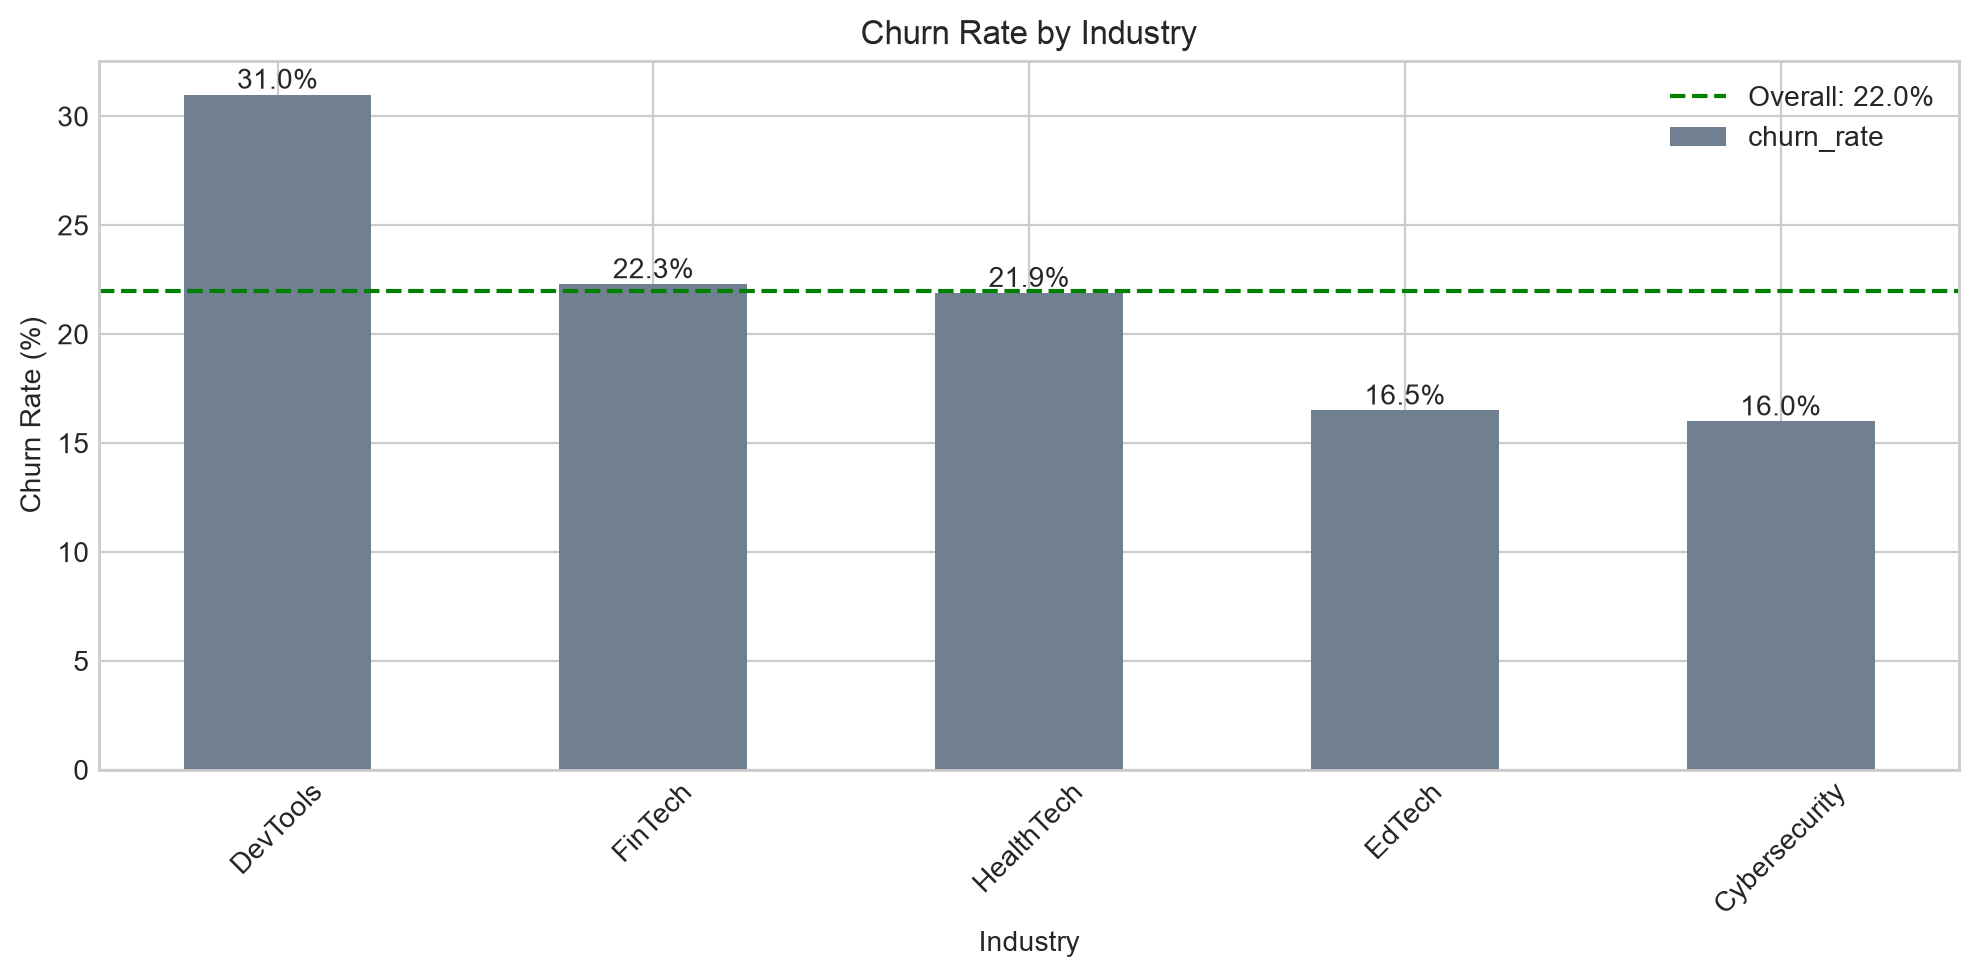

In [7]:
# TODO: 전체 및 세그먼트별 이탈률을 계산하세요.
# TODO: 산업별 이탈률 그래프를 그리세요.


# ============================================================
# 1. 전체 계정 이탈률
# ============================================================

overall_churn_rate = accounts["churn_flag"].mean()

print(f"전체 계정 이탈률 : {overall_churn_rate * 100:.1f}%")


# ============================================================
# 2. 세그먼트별 계정 수와 이탈률
# ============================================================

segment_results = {}

for column in ["industry","referral_source","is_trial"]:

    result = (
        accounts
        .groupby(column)
        .agg(
            account_count=("account_id", "nunique"),
            churn_rate=("churn_flag", "mean")
        )
        .reset_index()
    )

    # 백분율 컬럼
    result["churn_rate_pct"] = (result["churn_rate"] * 100).round(1)

    segment_results[column] = result

    print(f"\n[{column}]")
    display(result)


# ============================================================
# 3. 우선 확인할 고이탈 세그먼트
# ============================================================

high_churn_list = []


for column, result in segment_results.items():

    temp = result[
        (result["account_count"] >= 20)
        &
        (result["churn_rate"] > overall_churn_rate)
    ].copy()


    # 어떤 기준의 세그먼트인지 표시
    temp["segment_type"] = column

    # 세그먼트 값을 같은 컬럼으로 통일
    temp["segment"] = temp[column].astype(str)


    high_churn_list.append(
        temp[
            [
                "segment_type",
                "segment",
                "account_count",
                "churn_rate",
                "churn_rate_pct"
            ]
        ]
    )


high_churn_segments = pd.concat(
    high_churn_list,
    ignore_index=True
)


# 이탈률 높은 순서
high_churn_segments = high_churn_segments.sort_values("churn_rate",ascending=False).reset_index(drop=True)



print("[표본 20개 이상 + 전체 이탈률보다 높은 세그먼트]")

display(high_churn_segments)

# ============================================================
# 가장 높은 이탈률 세그먼트
# ============================================================

if len(high_churn_segments) > 0:

    top_segment = high_churn_segments.iloc[0]

    print("===== 우선 점검 세그먼트 =====")
    print("기준 :", top_segment["segment_type"])
    print("세그먼트 :",top_segment["segment"])
    print("계정 수 :",int(top_segment["account_count"]))
    print("이탈률 :",f'{top_segment["churn_rate_pct"]:.1f}%')
    print("전체 이탈률 :",f"{overall_churn_rate * 100:.1f}%")

# ============================================================
# 산업별 이탈률
# ============================================================

industry_result = segment_results["industry"].copy()


# 이탈률 높은 순서
industry_result = industry_result.sort_values("churn_rate_pct",ascending=False)



# ============================================================
# 그래프
# ============================================================

plt.figure(figsize=(10, 5))


bars = plt.bar(
    industry_result["industry"],
    industry_result["churn_rate_pct"],
    width=0.5,
    color='slategray',
    label='churn_rate'
)


# 막대 위 이탈률 표시
for bar, value in zip(bars,industry_result["churn_rate_pct"]):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


# 전체 이탈률 기준선
plt.axhline(
    overall_churn_rate * 100,
    linestyle="--",
    color='green',
    label=f"Overall: {overall_churn_rate * 100:.1f}%"
)


plt.title("Churn Rate by Industry")
plt.xlabel("Industry")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

### 필수 2 서술 답안

- 발견한 핵심 패턴: DevTools
- 문제 정의:
- 현재 지표: 계정 113개 중 35개가 이탈로 분류됨.
- 목표 지표: 31%->22%로 줄이는 것
- 목표 지표가 적절한 이유: 이탈 비중이 가장 높은 지표이므로 후속 분석의 대상으로 삼아야 함

|결과|수치의 의미|여기서 얻을 수 있는 판단|
|---|---|---|
|DevTools 31.0%|DevTools 계정 113개 중 35개가 이탈로 표시됨|이탈 비중이 높은 산업 집단이므로 후속 분석의 우선 대상으로 삼을 수 있음|
|event 30.2%|유입 경료가 event인 계정 96개 즁 29개가 이탈로 표시됨|이 유입 경로의 고객 구성과 이루 이용경험을 추가호 살펴볼 필요가 있음|
|체험 25.8% 비체험 21.1%|각각 97개 중 25개, 403개 중 85개가 이탈로 표시굄|체험 집단의 이탈 비중이 약 4.7%p 높지만 체험 제공이 이탈을 유발했다고 결론 내릴 수는 없음|

---

## 과제 1 — 이탈 원인 가설과 검증 계획 세우기

필수 2에서 정의한 문제를 바탕으로 초기 가설 3개를 작성하세요.

- 적어도 2개는 현재 제공된 데이터로 검증 가능해야 합니다.
- 각 가설에 `필요한 테이블·컬럼`, `확인할 비교 또는 지표`, `우선순위`를 적으세요.
- 가장 먼저 검증할 가설 1개를 고르고 이유를 설명하세요.
- 2강 분석 → 3강 실험 → 4강 제안이 처음 문제와 어떻게 연결되는지 한 문장씩 작성하세요.

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---:|---|---|---|
| 1 | **DevTools 이탈 계정은 유지 계정보다 기능 사용량이 적거나 오류가 많을 것이다.** | `accounts`: account_id, industry, churn_flag / `subscriptions`: subscription_id, account_id / `feature_usage`: usage_count, usage_duration_secs, error_count | DevTools 계정을 이탈/유지로 나누어 계정당 기능 사용량, 사용 일수, 오류 수, 사용시간을 비교한다. |
| 2 | **DevTools의 Trial 계정은 Non-Trial 계정보다 이탈률이 높을 것이다.** | `accounts`: industry, is_trial, churn_flag | DevTools 안에서 Trial과 Non-Trial의 계정 수 및 이탈률을 비교한다. |
| 3 | **DevTools 이탈 계정은 유지 계정보다 고객지원 경험이 좋지 않을 것이다.** | `accounts`: account_id, churn_flag / `support_tickets`: first_response_time_minutes, resolution_time_hours, satisfaction_score, escalation_flag | 이탈/유지 계정의 평균 응답시간, 해결시간, 만족도 등을 비교한다. |

### 프로젝트 연결

- 2강 분석: DevTools 계정이 가입 후 실제 기능 사용 단계까지 얼마나 도달하고 이후에도 반복적으로 기능을 사용하는지 퍼널과 리텐션으로 분석한다.

- 3강 실험: 2강에서 발견한 주요 이탈 구간을 개선하기 위한 온보딩 또는 기능 사용 경험 변경안을 A/B 테스트로 검증한다.

- 4강 제안: 분석과 실험 결과를 근거로 실제로 적용할 개선안과 기대 효과, 실행 우선순위를 제안한다.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?
    - DevTools 산업
    - 다른 산업군에 비해 이탈률이 높다

- 어떤 통계적·분석적 방법을 적용했는가?
    - 데이터 전처리, EDA

- 무엇을 근거로 결론을 내렸는가?
    - 전체 이탈률이 22.0%와 DevTools 이탈율 31.0% 정도, event유입 30.2%, 체험 계정 25.8%를 기준으로 결론을 내렸다.